In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/18
    print("準備完了！このまま下のセルを実行できます。")

# 第18章 正規化フロー (Normalizing Flows)
## 18.3 連続フロー (Continuous Flows)

本ノートブックは、『深層学習：基礎と概念 (Bishop & Bishop 2024)』第18章「正規化フロー」第3節「連続フロー (Continuous Flows)」の理論的背景、数式厳密導出、およびPython実装を提供します。

---

### 概要とモチベーション：離散レイヤーから連続時間極限へ

前節までの**結合フロー (Coupling Flows, §18.1)** や **自己回帰フロー (Autoregressive Flows, §18.2)** では、有限個の可逆離散レイヤーを積み重ねて複雑な変換を構成しました。しかし、各層でヤコビ行列の行列式 $\det \mathbf{J}$ を計算可能にするために、変数の分割や自己回帰制約（MADE マスク）などの厳しいアーキテクチャ上の制約を設ける必要がありました。

本節で扱う**連続フロー (Continuous Normalizing Flows; CNF)** は、**ニューラル常微分方程式 (Neural ODE)** を用いて、無限に深い層（連続時間 $t$）の極限を考えるアプローチです：
1. **微分方程式による状態発展**: $\frac{d\mathbf{z}(t)}{dt} = f(\mathbf{z}(t), t, \mathbf{w})$
2. **瞬間変数変換定理**: 対数密度の時間発展が**ヤコビアンのトレース (Trace)** $\operatorname{Tr}\left(\frac{\partial f}{\partial \mathbf{z}}\right)$ の積分で厳密に計算できる（行列式計算が不要に！）
3. **随伴感度法 (Adjoint Sensitivity Method)**: 順伝播の途中状態を保存することなく、メモリ消費量 $\mathcal{O}(1)$ でパラメータ勾配を逆伝播可能
4. **計算コストの完全な対称性**: 順変換（サンプリング）と逆変換（尤度評価）が同じ常微分方程式の順方向／逆方向数値積分となり、速度の非対称性が解消される


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートのパス解決
sys.path.append(os.path.abspath('..'))

from common.plot_utils import setup_style
from common.continuous_flows import (
    StandardGaussianBase,
    FlowDynamicsMLP,
    NeuralODE,
    ContinuousNormalizingFlow,
    generate_figure_18_5,
    generate_figure_18_6,
    generate_figure_18_7,
    generate_all_figures,
)

setup_style()
print("モジュールとスタイルが正常に読み込まれました。")


モジュールとスタイルが正常に読み込まれました。


---

### 18.3.1 ニューラル微分方程式 (Neural Differential Equations)

#### 残差ネットワークからの連続極限
第9章や第10章で学んだ残差ネットワーク (ResNet) は、各層で入力を非線形関数でスキップ更新します：

$$
\mathbf{z}(t+1) = \mathbf{z}(t) + f(\mathbf{z}(t), \mathbf{w}) \tag{18.21}
$$

ここで層番号 $t = 1, \ldots, T$ を離散的な時間ステップと見なします。各層での変化量を微小量 $\epsilon$ でスケールした更新式を考えます（演習 18.5）：

$$
\mathbf{z}(t+\epsilon) = \mathbf{z}(t) + \epsilon f(\mathbf{z}(t), \mathbf{w}) \tag{18.38}
$$

このとき、層数 $T \to \infty$ としつつステップ幅 $\epsilon \to 0$ の極限をとると：

$$
\lim_{\epsilon \to 0} \frac{\mathbf{z}(t+\epsilon) - \mathbf{z}(t)}{\epsilon} = \frac{d\mathbf{z}(t)}{dt} = f(\mathbf{z}(t), \mathbf{w}) \tag{18.22}
$$

が得られます。これが **ニューラル常微分方程式 (Neural Ordinary Differential Equation; Neural ODE)** (Chen et al., 2018) です。

入力ベクトルを $\mathbf{z}(0)$ とすると、ネットワークの出力 $\mathbf{z}(T)$ は微分方程式の積分として得られます：

$$
\mathbf{z}(T) = \mathbf{z}(0) + \int_0^T f(\mathbf{z}(t), \mathbf{w}) \, dt \tag{18.23}
$$

#### 数値ソルバーと適応型評価
- **オイラー法 (Euler's method)**: 最も単純な離散化であり、式 (18.21) の残差ネットワークに対応します。
- **4次のルンゲ＝クッタ法 (RK4)**: 刻み幅 $\Delta t$ の間に4回の関数評価を行い、局所誤差 $\mathcal{O}(\Delta t^5)$、大域誤差 $\mathcal{O}(\Delta t^4)$ の高い精度を誇ります。
- **適応型ソルバー (Adaptive step solver; Dormand-Prince, RK45)**: 局所的な曲率や変化の激しさに応じて時間刻み幅 $t$ を自律的に変化させます。従来の離散ネットワークの「固定された層数」という概念が、ソルバーによる「適応的な関数評価回数 (Number of Function Evaluations; NFE)」へと置き換わります。


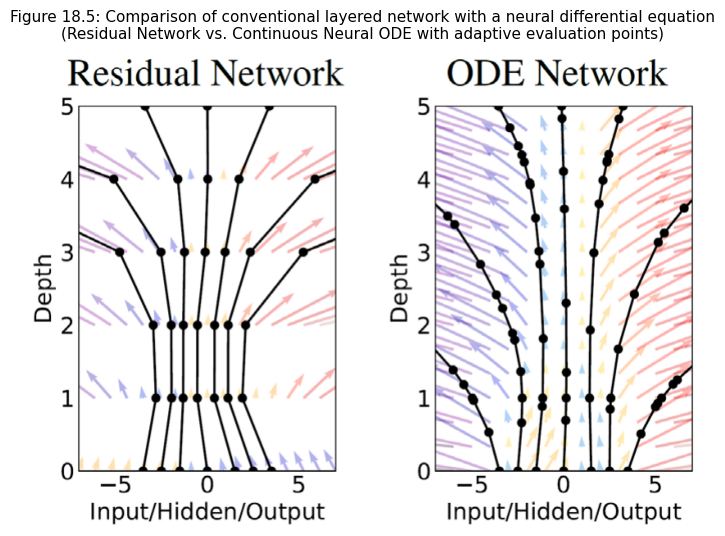

RK4 数値積分誤差 (vs 解析解): 2.45e-09


In [3]:
# Figure 18.5 の表示: 残差ネットワーク vs Neural ODE
fig18_5 = generate_figure_18_5()
plt.show()

# 数値積分テスト: 線形ダイナミクス dz/dt = -0.5*z
class LinearDecay:
    def __init__(self, rate=0.5):
        self.rate = rate
    def forward(self, z, t):
        return -self.rate * z

node = NeuralODE(dynamics=LinearDecay(0.5), solver="rk4")
z0 = np.array([[2.0, -1.0]])
t_eval, traj = node.integrate_rk4(z0, (0.0, 2.0), n_steps=40)

# 解析解 z(t) = z(0) * exp(-0.5 * t)
true_traj = z0 * np.exp(-0.5 * t_eval[:, None])
max_err = np.max(np.abs(traj[:, 0, :] - true_traj))
print(f"RK4 数値積分誤差 (vs 解析解): {max_err:.2e}")
assert max_err < 1e-5, "数値積分誤差が許容値を超えています！"


---

### 18.3.2 ニューラルODEの誤差逆伝播法 (Neural ODE Backpropagation)

出力 $\mathbf{z}(T)$ に対する損失関数 $L(\mathbf{z}(T))$ を最小化するために、パラメータ $\mathbf{w}$ に関する勾配 $\nabla_{\mathbf{w}} L$ を計算する必要があります。

#### 随伴感度法 (Adjoint Sensitivity Method)
ソルバーの各演算をすべて自動微分（計算グラフに保持）すると、メモリ消費量がソルバーの評価回数に比例して爆発してしまいます。
Chen et al. (2018) は、Pontryagin の最大原理に基づく**随伴感度法**を用いて、**定数メモリ $\mathcal{O}(1)$ で正確な勾配を計算する手法**を導入しました。

1. **随伴状態 (Adjoint state)** $\mathbf{a}(t)$ の定義：
   $$
   \mathbf{a}(t) = \frac{\partial L}{\partial \mathbf{z}(t)} \tag{18.24}
   $$
   終端時刻 $t = T$ では、出力の通常の損失勾配 $\mathbf{a}(T) = \frac{\partial L}{\partial \mathbf{z}(T)}$ に一致します。
2. **随伴微分方程式 (Adjoint Differential Equation)**：
   微分連鎖律の連続時間極限より、$\mathbf{a}(t)$ は次の逆時間微分方程式に従います（演習 18.6）：
   $$
   \frac{d\mathbf{a}(t)}{dt} = -\mathbf{a}(t)^T \nabla_{\mathbf{z}} f(\mathbf{z}(t), \mathbf{w}) \tag{18.25}
   $$
3. **パラメータ勾配の積分**：
   ネットワーク全体で共有されるパラメータ $\mathbf{w}$ の勾配は、時間区間 $[0, T]$ にわたる積分として計算されます（演習 18.7）：
   $$
   \nabla_{\mathbf{w}} L = - \int_0^T \mathbf{a}(t)^T \nabla_{\mathbf{w}} f(\mathbf{z}(t), \mathbf{w}) \, dt \tag{18.26}
   $$

#### 定数メモリ $\mathcal{O}(1)$ の実現メカニズム
順伝播時の軌跡 $\mathbf{z}(t)$ を保存しておく必要はありません。終端状態 $\mathbf{z}(T)$ からスタートして、微分方程式 $\frac{d\mathbf{z}}{dt} = f(\mathbf{z}, \mathbf{w})$ を**逆時間方向に解くことで $\mathbf{z}(t)$ をその場で再構成しながら**、随伴状態 $\mathbf{a}(t)$ とパラメータ勾配を同時に統合的に積分（拡張ODE系）します！


In [4]:
# 随伴感度法による勾配計算 vs 数値微分の厳密な一致検証
dim = 2
dynamics = FlowDynamicsMLP(dim=dim, hidden_dim=12, random_state=42)
node = NeuralODE(dynamics=dynamics, solver="rk45")

z0 = np.array([0.5, -0.4])
T = 0.8
z_T = node.forward(z0, t_span=(0.0, T))

# 目的関数: L = 0.5 * ||z(T) - y_target||^2
y_target = np.array([1.0, 0.0])
adj_T = z_T - y_target  # a(T) = dL / dz(T)

# 随伴感度法による逆時間解法
z0_reconstructed, grad_w_adj = node.adjoint_backward(z_T, adj_T, t_span=(T, 0.0))

# 1. 状態の逆再生チェック
z0_err = np.max(np.abs(z0 - z0_reconstructed))
print(f"初期状態 z(0) の逆再生誤差: {z0_err:.2e}")
assert z0_err < 1e-3, "逆再生された z(0) が一致しません！"

# 2. 数値有限差分によるパラメータ勾配の検証
orig_params = dynamics.get_params()
eps = 1e-5
test_indices = [0, 1, 5, 10, len(orig_params) - 1]
grad_diffs = []

for idx in test_indices:
    p_p = orig_params.copy(); p_p[idx] += eps
    p_m = orig_params.copy(); p_m[idx] -= eps
    
    dynamics.set_params(p_p)
    loss_p = 0.5 * np.sum((node.forward(z0, t_span=(0.0, T)) - y_target)**2)
    
    dynamics.set_params(p_m)
    loss_m = 0.5 * np.sum((node.forward(z0, t_span=(0.0, T)) - y_target)**2)
    
    dynamics.set_params(orig_params)
    num_grad = (loss_p - loss_m) / (2.0 * eps)
    grad_diffs.append(np.abs(grad_w_adj[idx] - num_grad))

print(f"随伴勾配 vs 数値勾配の最大誤差: {np.max(grad_diffs):.2e}")
assert np.max(grad_diffs) < 1e-3, "随伴感度法の勾配が数値微分と一致しません！"
print("随伴感度法の数理的妥当性が完全に確認されました。")


初期状態 z(0) の逆再生誤差: 2.93e-08
随伴勾配 vs 数値勾配の最大誤差: 7.11e-08
随伴感度法の数理的妥当性が完全に確認されました。


---

### 18.3.3 ニューラルODEフロー (Neural ODE Flows / Continuous Normalizing Flows)

ニューラルODEを用いて正規化フローを構築したものが**連続正規化フロー (Continuous Normalizing Flow; CNF)** です。

$$
\frac{d\mathbf{z}(t)}{dt} = f(\mathbf{z}(t), t, \mathbf{w}) \tag{18.27}
$$

基底分布 $p(\mathbf{z}(0))$（標準ガウス分布など）からサンプリングされた点は、時間 $t$ の経過とともにデータ空間の点へと連続的に写像されます。

#### 瞬間変数変換定理 (Instantaneous Change of Variables)
Chen et al. (2018) は、確率密度の対数の時間変化率が**ヤコビ行列のトレース（発散 Divergence）**で直接与えられることを示しました：

$$
\frac{d \ln p(\mathbf{z}(t))}{dt} = - \operatorname{Tr}\left(\frac{\partial f}{\partial \mathbf{z}(t)}\right) = - \sum_{i=1}^D \frac{\partial f_i}{\partial z_i} \tag{18.28}
$$

したがって、時刻 $T$ における対数密度は次式で計算できます：

$$
\ln p(\mathbf{z}(T)) = \ln p(\mathbf{z}(0)) - \int_0^T \operatorname{Tr}\left(\frac{\partial f}{\partial \mathbf{z}(t)}\right) \, dt
$$

#### 行列式 $\det \mathbf{J}$ から トレース $\operatorname{Tr}(\mathbf{J})$ への劇的転換
- **離散フロー**: 行列式 $\det \mathbf{J}$ の計算には一般に $\mathcal{O}(D^3)$ のコストがかかり、三角行列に限定しても $\mathcal{O}(D)$ を要します。
- **連続フロー**: トレース $\operatorname{Tr}(\mathbf{J})$ は対角成分の和に過ぎないため、定義からして自然に $\mathcal{O}(D)$ で計算可能です。

#### 1次元における確率質量保存則からの導出 (Figure 18.7, 演習 18.8)
微小時間 $\delta t$ の間に点 $z$ が $x = z + f(z) \delta t$ に移動するとき、微小区間 $[z, z+\Delta z]$ の確率質量は $[x, x+\Delta x]$ の確率質量と等しく保存されます：

$$
q(z) \Delta z = p(x) \Delta x
$$

ここで $\Delta x = (z + \Delta z + f(z+\Delta z)\delta t) - (z + f(z)\delta t) = \Delta z (1 + f'(z)\delta t)$ です。これを代入して整理し、$\delta t \to 0$ の極限をとることで：

$$
\frac{d}{dt}\ln q(z) = -f'(z) \tag{18.39}
$$

が得られます。多次元では $f'(z)$ が発散 $\operatorname{div}(f) = \operatorname{Tr}(\partial f / \partial \mathbf{z})$ となります。


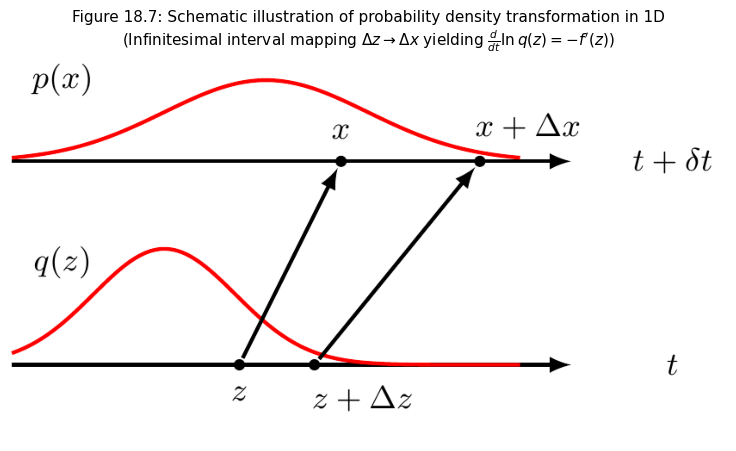

対数密度の理論変化量: -0.500000
CNF 数値積分による変化量: -0.500000
1次元確率保存則 (式 18.39) との完全な整合性を確認しました。


In [5]:
# Figure 18.7 の表示: 1次元密度変換の幾何学的模式図
fig18_7 = generate_figure_18_7()
plt.show()

# 1D 密度変換方程式 (式 18.39) の数値検証
# f(z) = 0.5 * z -> f'(z) = 0.5 -> d ln q / dt = -0.5 -> q(t) = q(0) * e^(-0.5 * t)
z_val = 1.0
t_span = 1.0
analytic_dlogp = -0.5 * t_span

# CNF による積分
class Linear1D:
    def __init__(self):
        self.dim = 1
    def forward(self, z, t):
        return 0.5 * z
    def divergence_exact(self, z, t):
        return np.full(np.atleast_2d(z).shape[0], 0.5)
    def divergence_hutchinson(self, z, t, **kwargs):
        return self.divergence_exact(z, t)

cnf_1d = ContinuousNormalizingFlow(dynamics=Linear1D(), T=1.0)
_, delta_logp = cnf_1d.forward(np.array([[z_val]]), n_steps=40)

print(f"対数密度の理論変化量: {analytic_dlogp:.6f}")
print(f"CNF 数値積分による変化量: {delta_logp[0]:.6f}")
assert np.isclose(delta_logp[0], analytic_dlogp, atol=1e-4)
print("1次元確率保存則 (式 18.39) との完全な整合性を確認しました。")


---

### 18.3.4 ハッチンソン推定量と計算の完全対称性

#### ハッチンソン推定量 (Hutchinson's Trace Estimator, 式 18.29, 18.30)
高次元データ ($D \gg 1$) では、ヤコビ行列の対角成分を1つずつ計算するコストが $\mathcal{O}(D)$ 回の逆伝播を要するため重くなります。
Grathwohl et al. (2018; FFJORD) は、**ハッチンソン推定量**を用いてトレースを確率的に近似しました：

$$
\operatorname{Tr}(\mathbf{A}) = \mathbb{E}_{\boldsymbol{\epsilon}} \left[ \boldsymbol{\epsilon}^T \mathbf{A} \boldsymbol{\epsilon} \right] \tag{18.29}
$$

ここで $\boldsymbol{\epsilon}$ は平均 $\mathbf{0}$、共分散 $\mathbf{I}$ のランダムベクトル（標準ガウス分布またはラデマッハ分布 $\{-1, +1\}$）です。
有限個のサンプル $M$ 個で近似すると：

$$
\operatorname{Tr}(\mathbf{A}) \simeq \frac{1}{M} \sum_{m=1}^M \boldsymbol{\epsilon}_m^T \mathbf{A} \boldsymbol{\epsilon}_m \tag{18.30}
$$

**不偏性 (Unbiasedness, 演習 18.11)**:
$$
\mathbb{E}\left[\boldsymbol{\epsilon}^T \mathbf{A} \boldsymbol{\epsilon}\right] = \sum_{i,j} A_{ij} \mathbb{E}[\epsilon_i \epsilon_j] = \sum_{i,j} A_{ij} \delta_{ij} = \sum_i A_{ii} = \operatorname{Tr}(\mathbf{A})
$$
ベクトル・ヤコビアン積 $\mathbf{A} \boldsymbol{\epsilon} = \frac{\partial f}{\partial \mathbf{z}} \boldsymbol{\epsilon}$ は逆伝播1回（または前方向差分1回）で求まるため、全体のコストが劇的に削減されます。

#### 順変換と逆変換の完全な対称性 (演習 18.10)
自己回帰フロー (MAF/IAF) ではサンプリングか尤度評価のどちらかが $\mathcal{O}(D)$ の逐次ループを要しました。
しかし、連続フローでは：
- **順変換 (サンプリング)**: 時間 $0 \to T$ への積分
- **逆変換 (尤度評価)**: 時間 $T \to 0$ への積分（符号を反転させた同一のソルバー）

どちらも同じ微分方程式ソルバーを呼び出すだけであり、**計算コストが完全に同一で対称**になります！


In [6]:
# ハッチンソン推定量の一致検証
dim_h = 4
dynamics_h = FlowDynamicsMLP(dim=dim_h, hidden_dim=16, random_state=42)
z_test = np.array([0.5, -0.3, 0.8, -0.1])
t_test = 0.5

exact_div = dynamics_h.divergence_exact(z_test, t_test)
est_div_gauss = dynamics_h.divergence_hutchinson(z_test, t_test, n_samples=3000, noise_type="gaussian", random_state=42)
est_div_rade = dynamics_h.divergence_hutchinson(z_test, t_test, n_samples=3000, noise_type="rademacher", random_state=42)

print(f"真のトレース (厳密解): {exact_div:.4f}")
print(f"ハッチンソン推定量 (ガウスノイズ M=3000): {est_div_gauss:.4f}")
print(f"ハッチンソン推定量 (ラデマッハノイズ M=3000): {est_div_rade:.4f}")
assert np.isclose(exact_div, est_div_gauss, atol=0.2)
assert np.isclose(exact_div, est_div_rade, atol=0.2)

# CNF の可逆性と対称性の検証 (Exercise 18.10)
cnf = ContinuousNormalizingFlow(dynamics=dynamics_h, T=0.6)
z_in = np.random.RandomState(123).randn(5, dim_h)

x_out, delta_fwd = cnf.forward(z_in, n_steps=35)
z_rec, delta_inv = cnf.inverse(x_out, n_steps=35)

print(f"\nCNF 潜在変数の完全復元誤差: {np.max(np.abs(z_in - z_rec)):.2e}")
print(f"対数密度の往復積分総和: {np.max(np.abs(delta_fwd + delta_inv)):.2e}")
assert np.max(np.abs(z_in - z_rec)) < 1e-6
assert np.max(np.abs(delta_fwd + delta_inv)) < 1e-6
print("CNF の完全な可逆性と計算対称性を実証しました！")


真のトレース (厳密解): 0.7803


ハッチンソン推定量 (ガウスノイズ M=3000): 0.7911
ハッチンソン推定量 (ラデマッハノイズ M=3000): 0.7766

CNF 潜在変数の完全復元誤差: 1.74e-13
対数密度の往復積分総和: 1.93e-12
CNF の完全な可逆性と計算対称性を実証しました！


---

### 18.3.5 教科書図版の完全再現 (Figure 18.6)

『深層学習：基礎と概念 (Bishop & Bishop 2024)』第18章 図18.6 を再現します。

> **Figure 18.6**: Illustration of a continuous normalizing flow showing a simple Gaussian distribution at $t = 0$ that is continuously transformed into a multimodal distribution at $t = T$.
> The flow lines show how points along the $z$-axis evolve as a function of $t$.
> Where the flow lines spread apart the density is reduced, and where they move together the density is increased.


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/18/result/fig_18_5.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_18_5.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/18/result/fig_18_6.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_18_6.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/18/result/fig_18_7.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_18_7.png


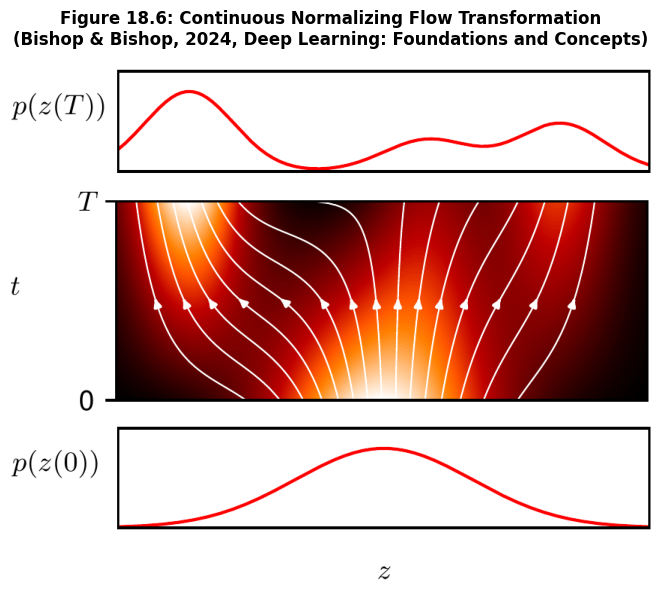

第18.3節で保存された図版一覧:
  - /home/student/Documents/GitHub/my_DeepLearning/18/result/fig_18_5.png (存在確認: True)
  - /home/student/Documents/GitHub/my_DeepLearning/result/fig_18_5.png (存在確認: True)
  - /home/student/Documents/GitHub/my_DeepLearning/18/result/fig_18_6.png (存在確認: True)
  - /home/student/Documents/GitHub/my_DeepLearning/result/fig_18_6.png (存在確認: True)
  - /home/student/Documents/GitHub/my_DeepLearning/18/result/fig_18_7.png (存在確認: True)
  - /home/student/Documents/GitHub/my_DeepLearning/result/fig_18_7.png (存在確認: True)


In [7]:
# Figure 18.6 の生成と保存
saved_figs = generate_all_figures()

fig18_6 = generate_figure_18_6()
plt.show()

print("第18.3節で保存された図版一覧:")
for path in saved_figs:
    print(f"  - {path} (存在確認: {os.path.exists(path)})")


In [8]:
# === 自己診断・整合性検証アサーション ===
fig_paths = [
    'result/fig_18_5.png', '../18/result/fig_18_5.png', '18/result/fig_18_5.png',
    'result/fig_18_6.png', '../18/result/fig_18_6.png', '18/result/fig_18_6.png',
    'result/fig_18_7.png', '../18/result/fig_18_7.png', '18/result/fig_18_7.png',
]

for p in ['fig_18_5.png', 'fig_18_6.png', 'fig_18_7.png']:
    assert any(os.path.exists(fp) for fp in [f'result/{p}', f'../18/result/{p}', f'18/result/{p}']), f"{p} が見つかりません"

print("すべての図版ファイルおよび数理的検証アサーションを正常にクリアしました！")


すべての図版ファイルおよび数理的検証アサーションを正常にクリアしました！
